# Self Organising Map Challenge

## The Kohonen Network

The Kohonen Self Organising Map (SOM) provides a data visualization technique which helps to understand high dimensional data by reducing the dimensions of data to a map. SOM also represents clustering concept by grouping similar data together.

Unlike other learning technique in neural networks, training a SOM requires no target vector. A SOM learns to classify the training data without any external supervision.

![Network](kohonen.png)

### Structure
A network has a width and a height that descibes the grid of nodes.  For example, the grid may be 4x4, and so there would be 16 nodes.

Each node has a weight for each value in the input vector.  A weight is simply a float value that the node multiplies the input value by to determine how influential it is (see below)

Each node has a set of weights that match the size of the input vector.  For example, if the input vector has 10 elements, each node would have 10 weights.

### Training 
To train the network

1. Each node's weights are initialized.
2. We enumerate through the training data for some number of iterations (repeating if necessary).  The current value we are training against will be referred to as the `current input vector`
3. Every node is examined to calculate which one's weights are most like the input vector. The winning node is commonly known as the Best Matching Unit (BMU).
4. The radius of the neighbourhood of the BMU is now calculated. This is a value that starts large, typically set to the 'radius' of the lattice,  but diminishes each time-step. Any nodes found within this radius are deemed to be inside the BMU's neighbourhood.
5. Each neighbouring node's (the nodes found in step 4) weights are adjusted to make them more like the input vector. The closer a node is to the BMU, the more its weights get altered.
6. Go to step 2 until we've completed N iterations.
    

### Calculating the Best Matching Unit (BMU)

To determine the best matching unit, one method is to iterate through all the nodes and calculate the Euclidean distance between each node's weight vector and the current input vector. The node with a weight vector closest to the input vector is tagged as the BMU.

The Euclidean distance $\mathsf{distance}_{i}$ (from the input vector $V$ to the $i$th node's weights $W_i$)is given as (using Pythagoras):

$$ \mathsf{distance}_{i}=\sqrt{\sum_{k=0}^{k=n}(V_k - W_{i_k})^2}$$

where V is the current input vector and $W_i$ is the node's weight vector.  $n$ is the size of the input & weight vector.

*Note*: $V$ and $W$ are vectors.  $V$ is the input vector, and $W_i$ is the weight vector of the $i$th node.  $V_k$ and $W_{i_k}$ represent the $k$'th value within those vectors.  

The BMU is the node with the minimal distance for the current input vector

### Calculating the Neighbourhood Radius

The next step is to calculate which of the other nodes are within the BMU's neighbourhood. All these nodes will have their weight vectors altered.

First we calculate what the radius of the neighbourhood should be and then use Pythagoras to determine if each node is within the radial distance or not.

A unique feature of the Kohonen learning algorithm is that the area of the neighbourhood shrinks over time. To do this we use the exponential decay function:

Given a desired number of training iterations $n$:
$$n_{\mathsf{max iterations}} = 100$$

Calculate the radius $\sigma_t$ at iteration number $t$:

$$\sigma_t = \sigma_0 \exp\left(- \frac{t}{\lambda} \right) \qquad t = 1,2,3,4... $$

Where $\sigma_0$ denotes the neighbourhood radius at iteration $t=0$, $t$ is the current iteration. We define $\sigma_0$ (the initial radius) and $\lambda$ (the time constant) as below:

$$\sigma_0 = \frac{\max(width,height)}{2} \qquad \lambda = \frac{n_{\mathsf{max iterations}}}{\log(\sigma_0)} $$

Where $width$ & $height$ are the width and height of the grid.

### Calculating the Learning Rate

We define the initial leanring rate $\alpha_0$ at iteration $t = 0$ as:
$$\alpha_0 = 0.1$$

So, we can calculate the learning rate at a given iteration t as:

$$\alpha_t = \alpha_0 \exp \left(- \frac{t}{\lambda} \right) $$

where $t$ is the iteration number, $\lambda$ is the time constant (calculated above)
        
### Calculating the Influence

As well as the learning rate, we need to calculate the influence $\theta_t$ of the learning/training at a given iteration $t$.  

So for each node, we need to caclulate the euclidean distance $d_i$ from the BMU to that node.  Similar to when we calculate the distance to find the BMU, we use Pythagoras.  The current ($i$th) node's x position is given by $x(W_i)$, and the BMU's x position is, likewise, given by $x(Z)$.  Similarly, $y()$ returns the y position of a node.

$$ d_{i}=\sqrt{(x(W_i) - x(Z))^2 + (y(W_i) - y(Z))^2} $$

Then, the influence decays over time according to:

$$\theta_t = \exp \left( - \frac{d_{i}^2}{2\sigma_t^2} \right) $$

Where $\sigma_t$ is the neighbourhood radius at iteration $t$ as calculated above. 

Note: You will need to come up with an approach to x() and y().


### Updating the Weights

To update the weights of a given node, we use:

$$W_{i_{t+1}} = W_{i_t} + \alpha_t \theta_t (V_t - W_{i_t})$$
        
So $W_{i_{t+1}}$ is the new value of the weight for the $i$th node, $V_t$ is the current value of the training data, $W_{i_t}$ is the current weight and $\alpha_t$ and $\theta_t$ are the learning rate and influence calculated above.

*Note*: the $W$ and $V$ are vectors 

### Example 10x10 network after 100 iterations

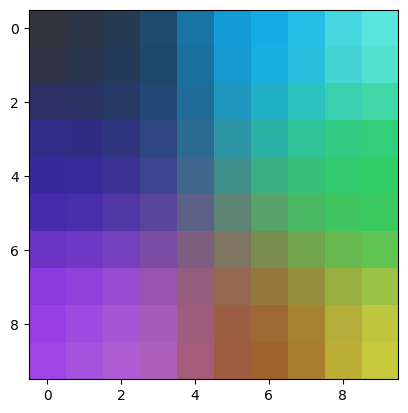

In [17]:
import matplotlib.pyplot as plt 
plt.imshow(image_data)

### Example 100x100 network after 1000 iterations

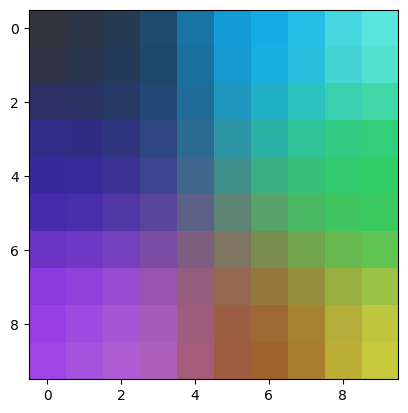

In [18]:
import matplotlib.pyplot as plt
plt.imshow(image_data)

## Challenge

Sam has written an implementation of a Self Organising Map. Consider the following criteria when assessing Sam's code:

- Could the code be made more efficient? A literal interpretation of the instructions above is not necessary.
- Is the code best structured for later use by other developers and in anticipation of productionisation?
- How would you approach productionising this application?
- Anything else you think is relevant.

In [19]:
# kohonen.py
import matplotlib.pyplot as plt
import numpy as np
def train(input_data, n_max_iterations, width, height):
    σ0 = max(width, height) / 2
    α0 = 0.1
    weights = np.random.random((width, height, 3))
    λ = n_max_iterations / np.log(σ0)
    for t in range(n_max_iterations):
        σt = σ0 * np.exp(-t/λ)
        αt = α0 * np.exp(-t/λ)
        for vt in input_data:
            bmu = np.argmin(np.sum((weights - vt) ** 2, axis=2))
            bmu_x, bmu_y = np.unravel_index(bmu, (width, height))
            for x in range(width):
                for y in range(height):
                    di = np.sqrt(((x - bmu_x) ** 2) + ((y - bmu_y) ** 2))
                    θt = np.exp(-(di ** 2) / (2*(σt ** 2)))
                    weights[x, y] += αt * θt * (vt - weights[x, y])
    return weights

if __name__ == '__main__':
    # Generate data
    input_data = np.random.random((10,3))
    image_data = train(input_data, 100, 10, 10)

    plt.imsave('100.png', image_data)

    # # Generate data
    # input_data = np.random.random((10,3))
    # image_data = train(input_data, 1000, 100, 100)

    # plt.imsave('1000.png', image_data)


## Original code: 
- One function contained multiple task
- 100 iterations took : x seconds  1000 iterations took : 10 min
-  Contains nested loops going through each node at a time 

## Making Sams code more effcient
- Removing loops and going through each node by adding vector function  [1,0,0,0] -> updating all nodes as once instead of doing it one by one
- Creating a Class: KohonenSOM: making code more modular/ can add more methods in / another dev can easily import it 
- adding logs: how long it takes to run n_iterations, adding a save method. storing the image_data so you dont need to run it again 
- Create Monitoring and track the class use, who is using it, 
- Containerise it into an app (docker) so multiple people can use it at the same time 


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
class KohonenSOM:
   def __init__(self,width,height,input_data):
       """Initialize the SOM with the specified width, height, and input data."""
       self.width = width
       self.height = height
       self.σ0 = max(width, height) / 2
       self.α0 = 0.1
       self.input_data = input_data
       self.seedquence = np.random.seed(42)
       self.weights = np.random.random((width, height, 3))
   def _map(self,n_max_iterations,t):
       """Calculate the time-dependent neighborhood radius σt and learning rate αt."""
       λ = n_max_iterations / np.log(self.σ0)
       σt = self.σ0 * np.exp(-t/λ)
       αt = self.α0 * np.exp(-t/λ)
       return σt, αt
   def _random_input(self, input_data):
       """Pick a random input vector from the input data."""
       vt = self.input_data[np.random.randint(0, len(input_data))]
       return vt
   def _find_bmu(self, vt):
       """Find the Best Matching Unit (BMU) for the input vector vt."""
       bmu = np.argmin(np.sum((self.weights - vt) ** 2, axis=2))
       return bmu
   def _calculate_θt(self, bmu_x, bmu_y, x_grid, y_grid, σt):
       """Calculates the neighborhood function θt for all nodes in the grid."""
       di = np.sqrt(((x_grid - bmu_x) ** 2) + ((y_grid - bmu_y) ** 2))
       θt = np.exp(-(di ** 2) / (2*(σt ** 2)))
       return θt
   def _calculate_bmu_coordinates(self, bmu):
       """Calculate the (x, y) coordinates of the BMU given its index."""
       bmu_x, bmu_y = np.unravel_index(bmu, (self.width, self.height))
       return bmu_x, bmu_y
   def _pick_random_colour(self):
       """Pick a random input vector from the input data."""
       vt = self.input_data[np.random.randint(0, len(self.input_data))]
       return vt
   def _create_vector(self):
       """Create a grid of (x, y) coordinates for the SOM."""
       x_grid, y_grid = np.meshgrid(np.arange(self.width), np.arange(self.height))
       return x_grid, y_grid
   def train(self,n_max_iterations):
       """Train the SOM using the input data for a specified number of iterations."""
       x_grid, y_grid = self._create_vector()
       for t in range(n_max_iterations):
           σt, αt = self._map(n_max_iterations,t)
           vt = self._pick_random_colour()
           bmu = self._find_bmu(vt)
           bmu_x, bmu_y = self._calculate_bmu_coordinates(bmu)
           θt = self._calculate_θt(bmu_x, bmu_y, x_grid, y_grid, σt)
           self.weights += αt * θt[..., np.newaxis] * (vt - self.weights)
       return self.weights
   def save_image(self, filename):
       """Save the current state of the SOM as an image file."""  
       folder_path = os.path.join(os.getcwd(), 'images')  
       os.makedirs(folder_path, exist_ok=True)
       path = os.path.join(folder_path, filename)
       plt.imsave(path, self.weights)
       return self.weights

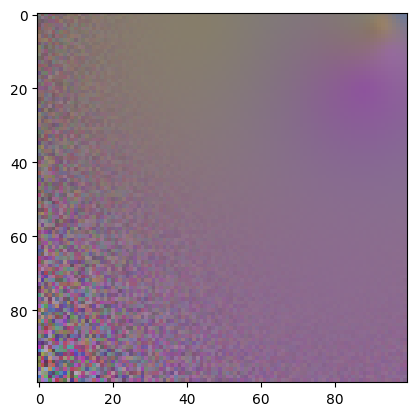

In [23]:
input_data = np.random.random((10,3))
# input_data = np.array([
#     [1, 0, 0],
#     [0.9, 0, 0],s
#     [0.8, 0.1, 0],
#     [0, 1, 0],s
#     [0, 0.9, 0],
#     [0, 0, 1],
#     [0, 0, 0.9]
# ])
som_instance1000 = KohonenSOM(width=100, height=100, input_data=input_data)
final_weights1000 = som_instance1000.train(n_max_iterations=1000)
save_path = som_instance1000.save_image('1000.png')
plt.imshow(save_path)

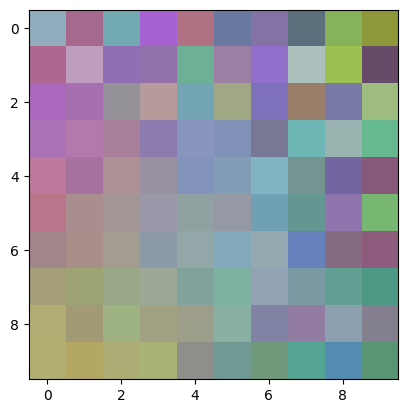

In [22]:
# input_data = np.random.random((5,3))
som_instance100 = KohonenSOM(width=10, height=10, input_data=input_data)
final_weights100 = som_instance100.train(n_max_iterations=100)
save_path = som_instance100.save_image('100.png')
plt.imshow(save_path)
# 